# Module 4 - Class 1: Linear Regression and Gradient Descent

**Dataset:** Superstore Sales  
**Objective:** Understand linear regression, evaluation metrics, and gradient descent.

### What you will learn
- Simple and multiple linear regression
- MSE, RMSE, MAE, R-squared
- Coefficient interpretation
- Residual analysis
- Polynomial features
- Gradient descent intuition

---

## 0. Setup

In [15]:
import pandas as pd # Import pandas library for data manipulation and structured data analysis
import numpy as np # Import numpy library for high-performance mathematical and numerical operations
import matplotlib.pyplot as plt # Import matplotlib.pyplot module for creating static, basic visualizations
import seaborn as sns # Import seaborn library for advanced statistical data visualization built on matplotlib
from sklearn.model_selection import train_test_split # Import train_test_split utility to split datasets into training and testing sets
from sklearn.linear_model import LinearRegression # Import LinearRegression class to build standard linear regression models
from sklearn.preprocessing import PolynomialFeatures # Import PolynomialFeatures to generate polynomial and interaction features
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score # Import evaluation metrics (MSE, MAE, R²) to measure model performance
import warnings # Import warnings module to manage and control runtime warning messages

warnings.filterwarnings('ignore') # Configure warning filter to ignore and hide all runtime warnings

print("Setup complete.") # Print a confirmation message to verify successful execution of the setup environment

Setup complete.


## 1. Load Data

In [16]:
# Superstore dataset  # Define a header comment indicating the dataset source
url = "https://raw.githubusercontent.com/Davron030901/Machine_Learning/main/data/superstore.csv"  # Store the raw GitHub URL of the superstore dataset into a variable
try:  # Start a try block to handle potential encoding errors while reading the file
    df = pd.read_csv(url, encoding='windows-1252')  # Attempt to read the CSV file from the URL using Windows-1252 character encoding
except Exception:  # Start an except block to catch any exceptions if the initial encoding fails
    df = pd.read_csv(url)  # Fall back to reading the CSV file from the URL using default UTF-8 encoding

print(f"Shape: {df.shape}")  # Print the total number of rows and columns (dimensions) of the loaded DataFrame
df.head()  # Display the first 5 rows of the DataFrame to inspect the data structure and content

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
# # Fallback: upload if URL fails
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0], encoding='windows-1252')

IndexError: list index out of range

In [18]:
# Quick inspection of numeric columns
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()  # Generate descriptive statistics such as count, mean, standard deviation, and percentiles for the specified numerical columns to summarize their distribution

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Simple Linear Regression: Sales ~ Discount

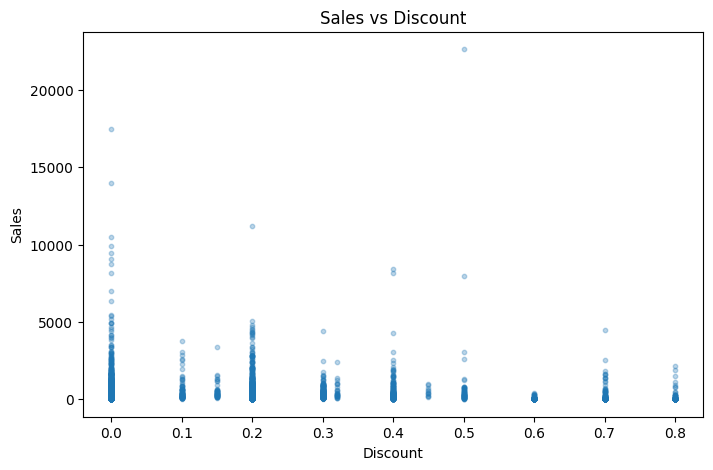

In [19]:
# Scatter plot to see the relationship
plt.figure(figsize=(8, 5))  # Set the width to 8 inches and height to 5 inches for the plot figure
plt.scatter(df['Discount'], df['Sales'], alpha=0.3, s=10)  # Create a scatter plot of Sales against Discount with 30% transparency and a marker size of 10
plt.xlabel('Discount')  # Label the horizontal x-axis as 'Discount'
plt.ylabel('Sales')  # Label the vertical y-axis as 'Sales'
plt.title('Sales vs Discount')  # Set the main title of the scatter plot visualization
plt.show()  # Render and display the final plot on the screen, clearing the current figure internal state

In [20]:
X_simple = df[['Discount']]  # Extract the 'Discount' column as the independent feature matrix (predictor)
y = df['Sales']  # Extract the 'Sales' column as the dependent target variable

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)  # Split the feature and target data into 80% training and 20% testing subsets with a fixed seed for reproducibility

# Train simple linear regression  # Write a section comment indicating the start of the simple linear regression model training
lr_simple = LinearRegression()  # Initialize an instance of the LinearRegression model class
lr_simple.fit(X_train, y_train)  # Fit the linear regression model using the training data to learn coefficients
y_pred_simple = lr_simple.predict(X_test)  # Generate predictions for the target variable using the testing feature subset

print(f"Coefficient (slope): {lr_simple.coef_[0]:.4f}")  # Output the calculated slope coefficient formatted to 4 decimal places
print(f"Intercept: {lr_simple.intercept_:.4f}")  # Output the calculated y-intercept value formatted to 4 decimal places
print(f"\nInterpretation: For each 1-unit increase in Discount,")  # Print the introductory text for the statistical interpretation of the model
print(f"Sales changes by {lr_simple.coef_[0]:.2f} on average.")  # Print the expected average change in sales per unit of discount formatted to 2 decimal places

Coefficient (slope): -126.7518
Intercept: 245.5065

Interpretation: For each 1-unit increase in Discount,
Sales changes by -126.75 on average.


## 3. Multiple Linear Regression

In [21]:
# Use multiple features
X_multi = df[['Discount', 'Quantity', 'Profit']]  # Extract 'Discount', 'Quantity', and 'Profit' columns as the multi-feature independent matrix

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)  # Split the multi-feature dataset into 80% training and 20% testing subsets with a fixed seed for reproducibility

lr_multi = LinearRegression()  # Initialize a new instance of the LinearRegression model class for multiple features
lr_multi.fit(X_train_m, y_train_m)  # Fit the multiple linear regression model using the multi-feature training data
y_pred_multi = lr_multi.predict(X_test_m)  # Generate target predictions using the multi-feature testing subset

# Coefficients
coef_df = pd.DataFrame({
    'Feature': X_multi.columns,
    'Coefficient': lr_multi.coef_
})  # Construct a DataFrame mapping each independent feature name to its corresponding learned regression coefficient
print("Coefficients:")  # Print a header label for the coefficients output section
print(coef_df.to_string(index=False))  # Display the coefficient DataFrame as a formatted string without printing row indices
print(f"\nIntercept: {lr_multi.intercept_:.4f}")  # Output the calculated y-intercept of the multiple regression model formatted to 4 decimal places

Coefficients:
 Feature  Coefficient
Discount   249.571780
Quantity    41.550264
  Profit     1.561674

Intercept: -18.0971


## 4. Evaluation Metrics

In [22]:
def evaluate_regression(y_true, y_pred, model_name="Model"):  # Define a custom function to calculate and display standard regression evaluation metrics
    """Compute and print regression metrics."""  # Docstring explaining that the function computes and prints regression evaluation metrics
    mse = mean_squared_error(y_true, y_pred)  # Calculate the Mean Squared Error between the actual and predicted target values
    rmse = np.sqrt(mse)  # Compute the Root Mean Squared Error by taking the square root of the calculated MSE
    mae = mean_absolute_error(y_true, y_pred)  # Calculate the Mean Absolute Error to measure the average magnitude of the errors
    r2 = r2_score(y_true, y_pred)  # Compute the R-squared score to determine the proportion of variance explained by the model

    print(f"--- {model_name} ---")  # Print a section header displaying the specified name of the model being evaluated
    print(f"MSE:  {mse:.2f}")  # Output the Mean Squared Error value formatted to 2 decimal places
    print(f"RMSE: {rmse:.2f}")  # Output the Root Mean Squared Error value formatted to 2 decimal places
    print(f"MAE:  {mae:.2f}")  # Output the Mean Absolute Error value formatted to 2 decimal places
    print(f"R2:   {r2:.4f}")  # Output the R-squared score formatted to 4 decimal places
    print()  # Print an empty line for clean visual separation in the console output
    return {'model': model_name, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}  # Return a dictionary containing the model name and all calculated evaluation metrics

metrics_simple = evaluate_regression(y_test, y_pred_simple, "Simple LR (Discount only)")  # Execute the function for the simple linear regression model and store its metrics dictionary
metrics_multi = evaluate_regression(y_test_m, y_pred_multi, "Multiple LR (Discount + Quantity + Profit)")  # Execute the function for the multiple linear regression model and store its metrics dictionary

--- Simple LR (Discount only) ---
MSE:  592714.18
RMSE: 769.88
MAE:  286.23
R2:   -0.0034

--- Multiple LR (Discount + Quantity + Profit) ---
MSE:  680377.46
RMSE: 824.85
MAE:  245.08
R2:   -0.1518



## 5. Coefficient Interpretation

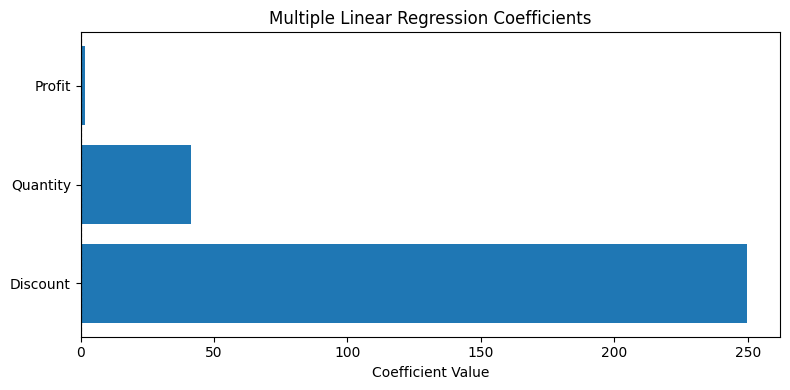

Each coefficient tells you: holding other features constant,
a 1-unit increase in this feature changes Sales by this amount.


In [23]:
# Visualize coefficients
plt.figure(figsize=(8, 4))  # Set the width to 8 inches and height to 4 inches for the plot figure
plt.barh(coef_df['Feature'], coef_df['Coefficient'])  # Create a horizontal bar chart plotting each feature name against its corresponding coefficient value
plt.xlabel('Coefficient Value')  # Label the horizontal x-axis as 'Coefficient Value'
plt.title('Multiple Linear Regression Coefficients')  # Set the main title of the horizontal bar chart visualization
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)  # Add a vertical dashed reference line at x=0 with a black color and a line width of 0.8
plt.tight_layout()  # Automatically adjust the padding around the plot to prevent labels from being clipped or overlapping
plt.show()  # Render and display the final bar plot on the screen, clearing the current figure internal state

print("Each coefficient tells you: holding other features constant,")  # Print the explanatory text for the ceteris paribus assumption in multiple regression coefficients
print("a 1-unit increase in this feature changes Sales by this amount.")  # Print the text explaining the expected average effect of a 1-unit feature increase on the target variable

## 6. Residual Plot

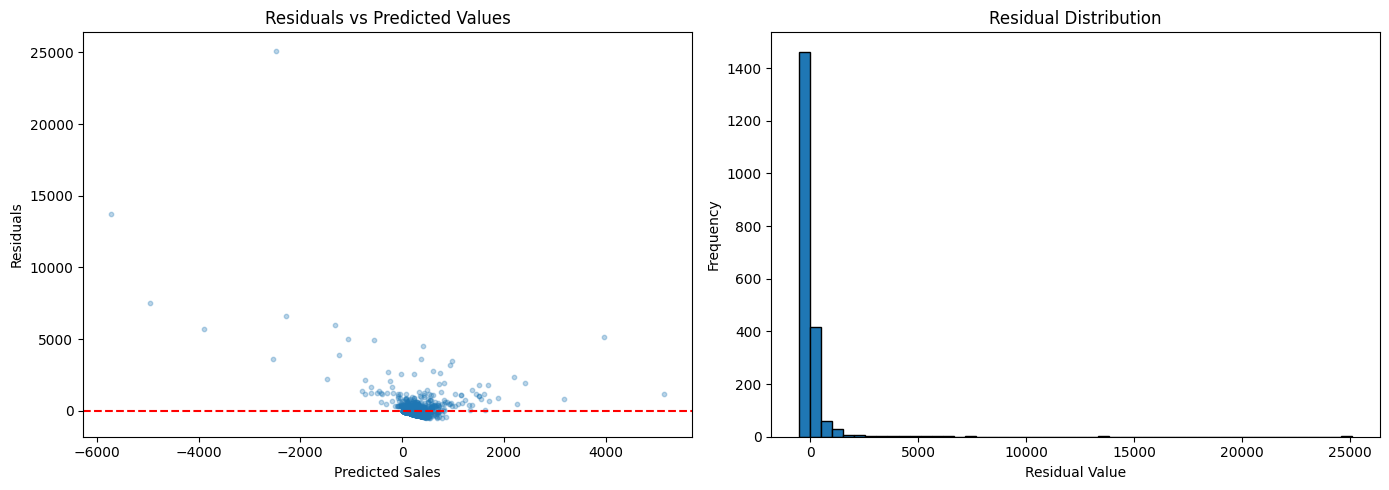

Ideal residual plot: randomly scattered around 0, no pattern.
A pattern suggests the model is missing something (non-linearity, interactions, etc.).


In [24]:
residuals = y_test_m - y_pred_multi  # Calculate the residuals by subtracting the multiple regression model's predicted sales from the actual test sales

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create a figure grid with 1 row and 2 columns of subplots, setting the overall width to 14 inches and height to 5 inches

# Residuals vs Predicted
axes[0].scatter(y_pred_multi, residuals, alpha=0.3, s=10)  # Create a scatter plot of predicted values versus residuals with 30% transparency and marker size of 10 on the first subplot
axes[0].axhline(y=0, color='red', linestyle='--')  # Draw a horizontal red dashed reference line at y=0 on the first subplot to indicate perfect predictions
axes[0].set_xlabel('Predicted Sales')  # Label the horizontal x-axis of the first subplot as 'Predicted Sales'
axes[0].set_ylabel('Residuals')  # Label the vertical y-axis of the first subplot as 'Residuals'
axes[0].set_title('Residuals vs Predicted Values')  # Set the title for the first subplot visualization

# Residual distribution
axes[1].hist(residuals, bins=50, edgecolor='black')  # Generate a histogram of the residuals divided into 50 bins with black outlines on the second subplot
axes[1].set_xlabel('Residual Value')  # Label the horizontal x-axis of the second subplot as 'Residual Value'
axes[1].set_ylabel('Frequency')  # Label the vertical y-axis of the second subplot as 'Frequency'
axes[1].set_title('Residual Distribution')  # Set the title for the second subplot visualization

plt.tight_layout()  # Automatically adjust layout spacing between and around the subplots to eliminate overlap
plt.show()  # Render and display both diagnostic plots on the screen, clearing the current figure internal state

print("Ideal residual plot: randomly scattered around 0, no pattern.")  # Print the text describing the optimal characteristics of a residual scatter plot
print("A pattern suggests the model is missing something (non-linearity, interactions, etc.).")  # Print the text explaining how structural patterns in residuals indicate model specification errors

## 7. TODO: Polynomial Features

Linear regression assumes a linear relationship. Polynomial features can capture non-linear patterns.

**Your tasks:**
1. Create polynomial features of degree 2 and degree 3
2. Train linear regression on each
3. Compare all models (linear, degree 2, degree 3) using the evaluation metrics

In [26]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)  # Initialize the PolynomialFeatures transformer to generate 2nd-degree interaction and squared terms without an intercept column
X_train_poly2 = poly2.fit_transform(X_train_m)  # Learn the feature mappings from the training data and transform it into 2nd-degree polynomial features
X_test_poly2 = poly2.transform(X_test_m)  # Transform the multi-feature testing subset into 2nd-degree polynomial features using the learned training configurations

lr_poly2 = LinearRegression()  # Initialize an instance of the LinearRegression model class for the 2nd-degree polynomial features
lr_poly2.fit(X_train_poly2, y_train_m)  # Fit the linear regression model using the 2nd-degree polynomial training feature matrix
y_pred_poly2 = lr_poly2.predict(X_test_poly2)  # Generate target predictions using the 2nd-degree polynomial testing feature matrix

metrics_poly2 = evaluate_regression(y_test_m, y_pred_poly2, "Polynomial LR (Degree 2)")  # Execute the evaluation function for the degree-2 polynomial model and store its metrics dictionary


poly3 = PolynomialFeatures(degree=3, include_bias=False)  # Initialize the PolynomialFeatures transformer to generate 3rd-degree interaction and cubic terms without an intercept column
X_train_poly3 = poly3.fit_transform(X_train_m)  # Learn the feature mappings from the training data and transform it into 3rd-degree polynomial features
X_test_poly3 = poly3.transform(X_test_m)  # Transform the multi-feature testing subset into 3rd-degree polynomial features using the learned training configurations

lr_poly3 = LinearRegression()  # Initialize an instance of the LinearRegression model class for the 3rd-degree polynomial features
lr_poly3.fit(X_train_poly3, y_train_m)  # Fit the linear regression model using the 3rd-degree polynomial training feature matrix
y_pred_poly3 = lr_poly3.predict(X_test_poly3)  # Generate target predictions using the 3rd-degree polynomial testing feature matrix

metrics_poly3 = evaluate_regression(y_test_m, y_pred_poly3, "Polynomial LR (Degree 3)")  # Execute the evaluation function for the degree-3 polynomial model and store its metrics dictionary

--- Polynomial LR (Degree 2) ---
MSE:  473873.85
RMSE: 688.38
MAE:  190.56
R2:   0.1978

--- Polynomial LR (Degree 3) ---
MSE:  467995.52
RMSE: 684.10
MAE:  177.83
R2:   0.2077



In [28]:
metrics_df = pd.DataFrame([
    metrics_simple,
    metrics_multi,
    metrics_poly2,
    metrics_poly3
])  # Construct a unified DataFrame from the dictionary objects containing the metrics for all four trained models

print("Model Comparison Table:")  # Print a section header label for the model performance summary table
print(metrics_df.round(2).to_string(index=False))  # Display the performance evaluation DataFrame rounded to two decimal places and formatted as a string without row indices

Model Comparison Table:
                                     model       MSE   RMSE    MAE    R2
                 Simple LR (Discount only) 592714.18 769.88 286.23 -0.00
Multiple LR (Discount + Quantity + Profit) 680377.46 824.85 245.08 -0.15
                  Polynomial LR (Degree 2) 473873.85 688.38 190.56  0.20
                  Polynomial LR (Degree 3) 467995.52 684.10 177.83  0.21


## 8. Gradient Descent Visualization (Demo)

This cell shows how gradient descent minimizes the loss function step by step. You do not need to modify this -- just run it and observe.

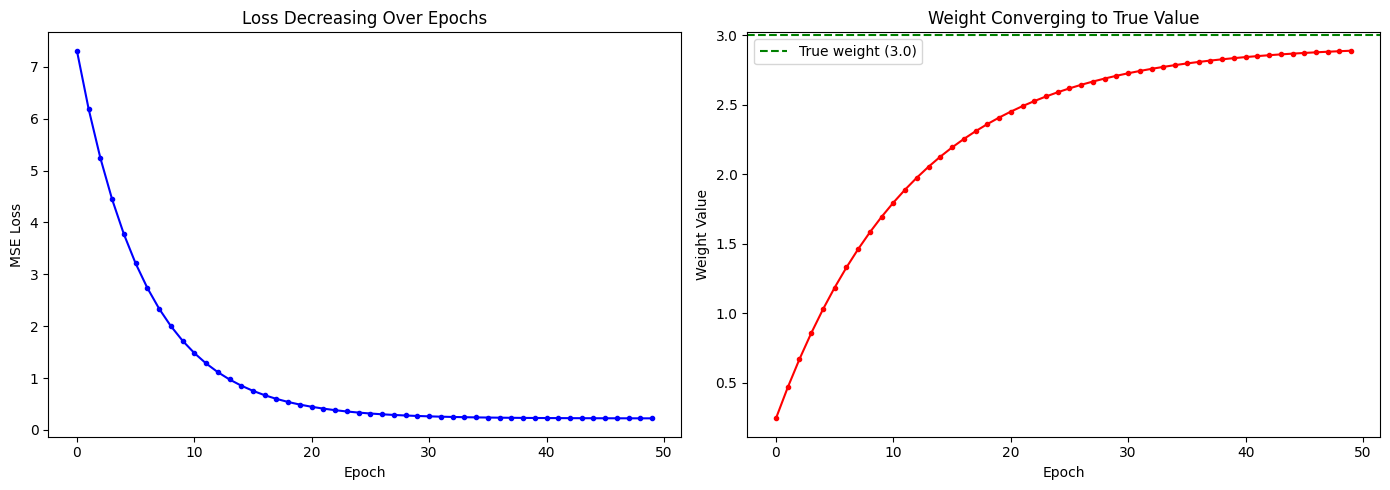

Final weight: 2.8889 (true: 3.0)
Final loss: 0.2224


In [29]:
# Simple gradient descent demo on a 1D problem  # Define a header comment introducing the 1D gradient descent optimization task
# Minimize MSE for: y = w * x (single weight, no bias)  # Specify the target objective of minimizing Mean Squared Error without an intercept term

np.random.seed(42)  # Set the pseudo-random number generator seed to 42 for reproducible data generation
x_gd = np.random.randn(100)  # Generate an array of 100 random values drawn from a standard normal distribution
y_gd = 3.0 * x_gd + np.random.randn(100) * 0.5  # Create the dependent target variable using a true slope of 3.0 and adding Gaussian noise

# Gradient descent
w = 0.0  # Initialize the weight parameter at zero before starting the optimization process
lr = 0.05  # Set the step size or learning rate for parameter updates to 0.05
n_epochs = 50  # Define the total number of iterations to run the gradient descent loop
history = []  # Initialize an empty list to store optimization metrics from each epoch

for epoch in range(n_epochs):  # Start the iterative optimization loop over the specified number of epochs
    # Prediction
    y_hat = w * x_gd  # Calculate predicted values using the current weight estimate
    # Loss (MSE)
    loss = np.mean((y_gd - y_hat) ** 2)  # Compute the Mean Squared Error loss between actual and predicted targets
    # Gradient: d(MSE)/dw = -2 * mean(x * (y - y_hat))
    grad = -2 * np.mean(x_gd * (y_gd - y_hat))  # Calculate the exact gradient of the loss function with respect to the weight parameter
    # Update
    w = w - lr * grad  # Update the weight parameter by moving in the opposite direction of the calculated gradient scaled by the learning rate
    history.append({'epoch': epoch, 'weight': w, 'loss': loss})  # Log the current epoch number, weight value, and loss into the history list

history_df = pd.DataFrame(history)  # Convert the logged optimization history from a list of dictionaries into a structured DataFrame

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # Create a layout grid with 1 row and 2 columns of subplots with a size of 14 by 5 inches

# Loss over epochs
axes[0].plot(history_df['epoch'], history_df['loss'], 'b-o', markersize=3)  # Plot the training loss against epoch numbers using a blue line with small circular markers
axes[0].set_xlabel('Epoch')  # Label the horizontal x-axis of the first subplot as 'Epoch'
axes[0].set_ylabel('MSE Loss')  # Label the vertical y-axis of the first subplot as 'MSE Loss'
axes[0].set_title('Loss Decreasing Over Epochs')  # Set the main title for the loss visualization subplot

# Weight convergence
axes[1].plot(history_df['epoch'], history_df['weight'], 'r-o', markersize=3)  # Plot the weight values across epochs using a red line with small circular markers
axes[1].axhline(y=3.0, color='green', linestyle='--', label='True weight (3.0)')  # Draw a horizontal green dashed reference line showing the target true weight value
axes[1].set_xlabel('Epoch')  # Label the horizontal x-axis of the second subplot as 'Epoch'
axes[1].set_ylabel('Weight Value')  # Label the vertical y-axis of the second subplot as 'Weight Value'
axes[1].set_title('Weight Converging to True Value')  # Set the main title for the parameter tracking subplot
axes[1].legend()  # Display the legend containing the reference line label on the second subplot

plt.tight_layout()  # Adjust the bounding box padding around the subplots to ensure clean arrangement without overlaps
plt.show()  # Render and display both diagnostic visualization plots on the screen, clearing the active figure state

print(f"Final weight: {w:.4f} (true: 3.0)")  # Output the final optimized weight value formatted to 4 decimal places alongside the target true value
print(f"Final loss: {history_df['loss'].iloc[-1]:.4f}")  # Output the last recorded loss value from the training dataframe formatted to 4 decimal places

---
## Summary

| Concept | Details |
|---------|---------|
| Simple LR | One feature predicting target |
| Multiple LR | Multiple features |
| MSE / RMSE | Penalize large errors more |
| MAE | Average absolute error (robust to outliers) |
| R-squared | Proportion of variance explained (0 to 1) |
| Residuals | Predicted - Actual; should be random around 0 |
| Polynomial | Captures non-linear relationships |
| Gradient Descent | Iteratively adjusts weights to minimize loss |